In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import time

##Functions##

In [11]:
def pmx_crossover(parent1, parent2):
    cutoff_1, cutoff_2 = np.sort(np.random.choice(np.arange(len(parent1)+1), size=2, replace=False))

    def PMX_one_offspring(p1, p2):
        offspring = np.zeros(len(p1), dtype=p1.dtype)

        # Copy the mapping section (middle) from parent1
        offspring[cutoff_1:cutoff_2] = p1[cutoff_1:cutoff_2]

        # copy the rest from parent2 (provided it's not already there
        for i in np.concatenate([np.arange(0,cutoff_1), np.arange(cutoff_2,len(p1))]):
            candidate = p2[i]
            while candidate in p1[cutoff_1:cutoff_2]: # allows for several successive mappings
                candidate = p2[np.where(p1 == candidate)[0][0]]
            offspring[i] = candidate
        return offspring

    offspring1 = PMX_one_offspring(parent1, parent2)
    offspring2 = PMX_one_offspring(parent2, parent1)

    return offspring1, offspring2



def edge_crossover(parent1, parent2):

    child1 = parent1[:]
    child2 = parent2[:]

    pt1 = random.randint(0, len(parent1) - 1)
    pt2 = random.randint(0, len(parent1) - 1)
    start = min(pt1, pt2)
    end = max(pt1, pt2)

    # Get edge values
    edge1 = parent1[start:end+1]
    edge2 = parent2[start:end+1]

    # Crossover edges
    child1[start:end+1] = edge2
    child2[start:end+1] = edge1

    # Remove duplicates
    for i in edge1:
        if i in child1 and i not in edge2:
            idx = child1.index(i)
            child1[idx] = None
    child1 = [i for i in child1 if i is not None]

    for i in edge2:
        if i in child2 and i not in edge1:
            idx = child2.index(i)
            child2[idx] = None
    child2 = [i for i in child2 if i is not None]

    # Repair missing values
    remaining = [item for item in parent1 + parent2 if item not in child1]
    for i in range(len(child1)):
        if child1[i] is None:
            child1[i] = remaining.pop(0)

    remaining = [item for item in parent1 + parent2 if item not in child2]
    for i in range(len(child2)):
        if child2[i] is None:
            child2[i] = remaining.pop(0)

    return child1, child2



def swap_mutation(chromosome):

    mutant = chromosome.copy()

    pt1 = random.randint(0, len(mutant)-1)
    pt2 = random.randint(0, len(mutant)-1)

    mutant[pt1], mutant[pt2] = mutant[pt2], mutant[pt1]

    return mutant


def insert_mutation(chromosome):

    mutant = list(chromosome)

    pt1 = random.randint(0, len(mutant)-1)
    pt2 = random.randint(0, len(mutant)-1)

    gene = mutant.pop(max(pt1, pt2))
    mutant.insert(min(pt1, pt2)+1, gene)
    return np.array(mutant)

Edge Recombination Crossover

In [12]:
def create_edge_list(parent):
    edge_list = {}
    size = len(parent)
    for i, node in enumerate(parent):
        edges = set()
        # Add the previous and next nodes in the cycle
        edges.add(parent[i - 1])
        edges.add(parent[(i + 1) % size])
        edge_list[node] = edges
    return edge_list

def edge_crossover(parent1, parent2):
    # Create edge lists for both parents
    edge_list1 = create_edge_list(parent1)
    edge_list2 = create_edge_list(parent2)

    # Combine the edge lists
    combined_edge_list = {node: edge_list1[node] | edge_list2[node] for node in edge_list1}
    combined_edge_plus_list = {node: edge_list1[node] & edge_list2[node] for node in edge_list1}

    # Start with a random node
    current_node = random.choice(parent1)
    # current_node = 1
    offspring = [current_node]

    while len(offspring) < len(parent1):
        # Remove the current node from the edge lists
        for edges in combined_edge_list.values():
            edges.discard(current_node)
        for edges in combined_edge_plus_list.values():
            edges.discard(current_node)

        # if there is a common edge, pick that to be the next elemnt
        if combined_edge_plus_list[current_node]:
            next_node = list(combined_edge_plus_list[current_node])[0]
        # Select the next node with the fewest edges
        elif combined_edge_list[current_node]:
            next_node = min(combined_edge_list[current_node], key=lambda x: len(combined_edge_list[x]))
        else:
            # If no edges left, pick a random unvisited node
            unvisited = set(parent1) - set(offspring)
            next_node = random.choice(list(unvisited))

        offspring.append(next_node)
        current_node = next_node
    return np.array(offspring)

In [13]:
# Initialzie the first population as the first generation
def initialize_population (POPULATION_SIZE = 100) -> list[np.ndarray]:
  population = []

  for i in range(POPULATION_SIZE):
    temp = np.arange(127)
    np.random.shuffle(temp)
    population.append(temp)


  return population
# print(f'length of an individual: {len(initialize_population(POPULATION_SIZE)[0])}')
# print(f'Number of the population: {len(initialize_population(POPULATION_SIZE))}')
# print(f'Represent of a random individual: \n {initialize_population(POPULATION_SIZE)[0]}')

In [14]:
def calculate_distance() -> np.ndarray:
  coords = np.loadtxt('TSPDATA.txt', usecols=(1,2), skiprows=2) # Returns the city cordinates

  num_cities = len(coords)
  dist_matrix = np.zeros((num_cities, num_cities))
  for i in range(num_cities):
    for j in range(num_cities):
      dist_matrix[i,j] = np.linalg.norm(coords[i]-coords[j])
  # print(f'Sample distance matrix: {dist_matrix[:1, :1]}')
  # print(f'distance matrix shape: {dist_matrix.shape}')

  return dist_matrix

dist_matrix = calculate_distance()

In [15]:
def fitness (individual: np.ndarray) -> np.float64:
  fitness = 0
  for i in range(len(individual) - 1):
    fitness += dist_matrix[individual[i], individual[i+1]]
  return 1 / fitness

In [16]:
# Rank-based roulette wheel
def linear_ranking(population: list[np.ndarray], fitnesses: list , s = 1.5) -> np.ndarray:
  population_temp = list(map(list, population))
  pop_fit = list(zip(population_temp, fitnesses))
  ranked_population = sorted(pop_fit, key=lambda x: x[1])
  probabilities = np.zeros(len(population))
  for rank in range(len(ranked_population)):
      probabilities[rank] = (2 - s) / len(population) + (2 * rank * (s - 1)) / (len(population) * (len(population) - 1))
  reordered_population = [np.array(x[0]) for x in ranked_population]
  return reordered_population, probabilities

# fitness Proportionate Selection
def fps(fitnesses: list):
    probabilities = np.zeros(len(fitnesses))
    fitnesses_sum = np.sum(fitnesses)
    for i in range(len(fitnesses)):
        probabilities[i] = fitnesses[i] / fitnesses_sum
    return probabilities

# Roulette Wheel Selection Algorithm
def roulette_wheel(probabilities, population: list[np.ndarray]):
  wheel = []
  sum_probabilites = 0

  for p in probabilities:
        sum_probabilites += p
        wheel.append(sum_probabilites)
  r = np.random.rand()

  for i in range(len(wheel)):
        if i == 0 and r <= wheel[i]:
            return population[i]
        elif wheel[i-1] < r <= wheel[i]:
            return population[i]

## Reading the dataset and Setting Parameters ##

In [19]:
cities = []
with open('./TSPDATA.txt') as f:
    lines = f.readlines()[2:]
    for line in lines:
        id, x, y = [int(num) for num in line.split()]
        cities.append((x, y))

print(f"The way we read city cordinates e.g. 3 cities: \n{cities[:3]}")

The way we read city cordinates e.g. 3 cities: 
[(9860, 14152), (9396, 14616), (11252, 14848)]


In [20]:
POPULATION_SIZE = 100
GENERATIONS = 1000
MUTATION_RATE = 0.1

## EA (1): ##
*   Parent selection -> Linear Ranking
*   Cross Over -> PMX
*   Mutation -> Swap




In [21]:
population = initialize_population()
best_fitness_per_generation = []
best_fitness = 0

start = time.time()
for i in range(GENERATIONS):

  pop_fitness = [fitness(ind) for ind in population]
  f_best = np.max(pop_fitness)
  best_fitness_per_generation.append(f_best)

  if f_best > best_fitness:
    best_fitness = f_best
    best_individual = population[pop_fitness.index(f_best)]

  print(f'best fitness of Generation {i+1}: {1 / f_best}')

  # Parent Selection:
  offspring = []
  population, probs = linear_ranking(population, pop_fitness, s = 1.5)
  for i in range(0, POPULATION_SIZE):
    p1 = roulette_wheel(probs, population)
    p2 = roulette_wheel(probs, population)
    while np.array_equal(p2, p1):
        p2 = roulette_wheel(probs, population)
    c1, c2 = pmx_crossover(p1, p2)
    offspring.append(c1)
    offspring.append(c2)

  # Mutation
  mutated_offspring = []
  for i in range(len(offspring)):
    if np.random.rand() < MUTATION_RATE:
      mutated_offspring.append(swap_mutation(offspring[i]))
  offspring += mutated_offspring

  offspring_fitness = [fitness(ind) for ind in offspring]
  population += offspring
  pop_fitness += offspring_fitness

  # Survival selection
  nextgen = []
  i = 0
  population, probs = linear_ranking(population, pop_fitness, s = 1.5)
  while i < POPULATION_SIZE:
    p = roulette_wheel(probs, population)
    p = list(p)
    if p not in nextgen:
      nextgen.append(p)
      i += 1

  population = list(map(np.array, nextgen))




end = time.time()
spent_time = end - start

best fitness of Generation 1: 573017.9577450852
best fitness of Generation 2: 572776.2232715135
best fitness of Generation 3: 574588.4200564446
best fitness of Generation 4: 547805.0539996506
best fitness of Generation 5: 547805.0539996506
best fitness of Generation 6: 562557.9585918704
best fitness of Generation 7: 547696.4429424189
best fitness of Generation 8: 548480.761486893
best fitness of Generation 9: 551747.7975380077
best fitness of Generation 10: 551747.7975380077
best fitness of Generation 11: 547150.0187623722
best fitness of Generation 12: 540860.3075385896
best fitness of Generation 13: 539184.3423459476
best fitness of Generation 14: 539184.3423459476
best fitness of Generation 15: 548085.8874610945
best fitness of Generation 16: 540308.1092277175
best fitness of Generation 17: 535724.6679374094
best fitness of Generation 18: 538605.6875225377
best fitness of Generation 19: 533267.6576626655
best fitness of Generation 20: 531732.4775167821
best fitness of Generation 21:

best fitness of all generations: 235850.41548292176
Time Spent to complete the algorithm is for 1000 Generations: 162.62 seconds


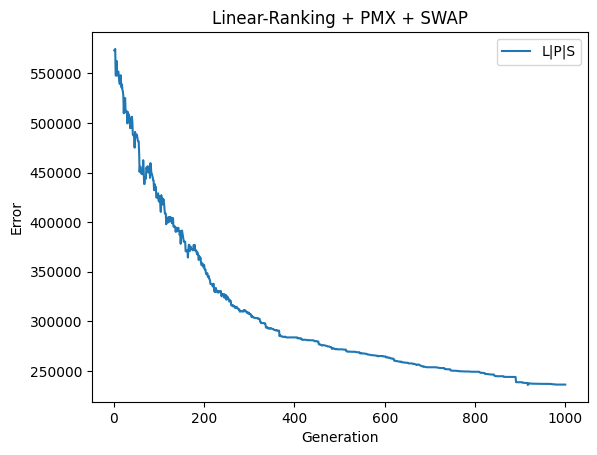

In [22]:
# print, report, and visualize previous cell information
print(f'best fitness of all generations: {1 / best_fitness}')
print(f"Time Spent to complete the algorithm is for {GENERATIONS} Generations: {np.round(spent_time, 2)} seconds")

x = [i for i in range (1, GENERATIONS + 1)]
best_fitness_per_generation = [1 / best_fitness_per_generation[i] for i in range(len(best_fitness_per_generation))]

plt.plot(x, best_fitness_per_generation, label='L|P|S')

plt.xlabel('Generation')
plt.ylabel('Error')
plt.title('Linear-Ranking + PMX + SWAP')

plt.legend()
plt.show()

In [36]:
# Best Route:
best_individual

array([ 83, 116,  78,  17,  23,  10,  89,  63,  57,  12,  56,  50,   1,
        21,  20,  16,  18,  59,  58,  61,  88,  91,  98, 124, 112,  64,
        99, 113, 105,  14,  13,  29,  33,  42,  34,  49, 120,  53, 123,
        54,  90,  60, 115,  75,  74,  87, 109,  70,   2, 119, 107,  31,
        28,  27, 126,  92, 117,  45, 111, 110, 106,  97,  96, 122,  93,
        46,  48,  43,  44, 102,  80,  82,  81, 100, 101,  62,  26,  30,
        25,  32, 121,  86,  85,  84, 103,  65,  55,  52,  47,  94,  39,
        36,   0, 114,   6, 104,  22,  72,  73,  68, 118,  95, 108,  69,
        67,  71,   9,  51,   4,   5,   8,   7,  66, 125,  79,  77,  15,
        35,  40,  41,  38,  24,  37,  11,  19,   3,  76])

## EA (2): ##
*   Parent selection -> Linear Ranking
*   Cross Over -> PMX
*   Mutation -> Insert




In [37]:
population = initialize_population()

best_fitness_per_generation = []

best_fitness = 0

start = time.time()
for i in range(GENERATIONS):
  # print(f'Generation {i}:', end="")
  pop_fitness = [fitness(ind) for ind in population]

  f_best = np.max(pop_fitness)
  best_fitness_per_generation.append(f_best)

  if f_best > best_fitness:
    best_fitness = f_best
    best_individual = population[pop_fitness.index(f_best)]

  print(f'best fitness of generation {i+1}: {1 / f_best}')

  # Parent Selection:
  offspring = []
  population, probs = linear_ranking(population, pop_fitness, s = 1.5)
  for i in range(0, POPULATION_SIZE):
    p1 = roulette_wheel(probs, population)
    p2 = roulette_wheel(probs, population)
    while np.array_equal(p2, p1):
        p2 = roulette_wheel(probs, population)
    c1, c2 = pmx_crossover(p1, p2)
    offspring.append(c1)
    offspring.append(c2)

  # Mutation
  mutated_offspring = []
  for i in range(len(offspring)):
    if np.random.rand() < MUTATION_RATE:
      mutated_offspring.append(insert_mutation(offspring[i]))
  offspring += mutated_offspring

  offspring_fitness = [fitness(ind) for ind in offspring]
  population += offspring
  pop_fitness += offspring_fitness
  # Survival selection
  nextgen = []
  i = 0
  population, probs = linear_ranking(population, pop_fitness, s = 1.5)
  while i < POPULATION_SIZE:
    p = roulette_wheel(probs, population)
    p = list(p)
    if p not in nextgen:
      nextgen.append(p)
      i += 1

  population = list(map(np.array, nextgen))




end = time.time()
spent_time = end - start

best fitness of generation 1: 578180.6145307493
best fitness of generation 2: 571181.0031474216
best fitness of generation 3: 571302.5287666571
best fitness of generation 4: 562848.452647603
best fitness of generation 5: 560316.3481231955
best fitness of generation 6: 562848.452647603
best fitness of generation 7: 555118.7785657359
best fitness of generation 8: 555118.7785657359
best fitness of generation 9: 558324.7873473053
best fitness of generation 10: 544435.2584451428
best fitness of generation 11: 536433.7274926424
best fitness of generation 12: 531858.4885364913
best fitness of generation 13: 558281.7856992974
best fitness of generation 14: 551062.283184464
best fitness of generation 15: 548759.1926294587
best fitness of generation 16: 540953.5463909783
best fitness of generation 17: 538436.9456778616
best fitness of generation 18: 547731.8575634868
best fitness of generation 19: 534114.2377890261
best fitness of generation 20: 534114.2377890261
best fitness of generation 21: 5

best fitness of all generations: 244519.6336305021
Time Spent to complete the algorithm is for 1000: 183.82 seconds


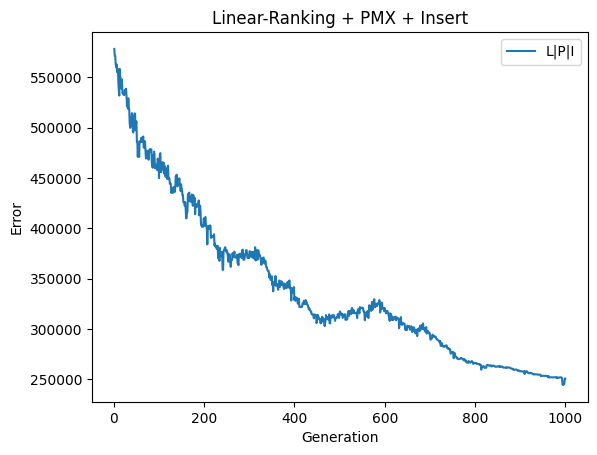

In [38]:
# report
print(f'best fitness of all generations: {1 / best_fitness}')
print(f"Time Spent to complete the algorithm is for {GENERATIONS}: {np.round(spent_time, 2)} seconds")

x = [i for i in range (1, GENERATIONS + 1)]
best_fitness_per_generation = [1 / best_fitness_per_generation[i] for i in range(len(best_fitness_per_generation))]

plt.plot(x, best_fitness_per_generation, label='L|P|I')

plt.xlabel('Generation')
plt.ylabel('Error')
plt.title('Linear-Ranking + PMX + Insert')

plt.legend()
plt.show()

In [39]:
# Route
best_individual

array([ 23,   7,  66,  72,  17,   6,   0,  40,  34,  35,  36,  49, 102,
        39,  33, 121,  27,  94,  92, 126,  24,  78,  80,  83, 116,  25,
        37,  26,  30,  79, 101, 100,  97, 106, 110,  45,  48,  65,  61,
        63,  84,  87, 109,  77, 125,  81,   8,  10,  12,  50, 120,  46,
        43,  28,  32,  29,  11,  15, 105, 113,  55, 123,  51,  70,  85,
        86, 108,  95,  58,  59, 112, 124, 115,  75,  74, 118,  62,  82,
        68,  69,  67,   1,  56,  54,  52,  93, 111,  64,  98,  91,  88,
       103,  60,  57,  99,   4, 117,  47,  44,  53, 119,   9,   2,  22,
        71,  18,  90,  89, 114,  42,  41,  38, 122,  96,  31,  76,  73,
        20,  21,  16,   3,  19, 104,  14, 107,   5,  13])

## EA (3): ##
*   Parent selection -> Linear Ranking
*   Cross Over -> Edge
*   Mutation -> Swap




In [40]:
population = initialize_population()
best_fitness_per_generation = []
best_fitness = 0

start = time.time()
for i in range(GENERATIONS):
  # print(f'Generation {i}:', end="")
  pop_fitness = [fitness(ind) for ind in population]

  f_best = np.max(pop_fitness)
  best_fitness_per_generation.append(f_best)

  if f_best > best_fitness:
    best_fitness = f_best
    best_individual = population[pop_fitness.index(f_best)]

  print(f'best fitness of generation {i+1}: {1 / f_best}')

  # Parent Selection:
  offspring = []
  population, probs = linear_ranking(population, pop_fitness, s = 1.5)
  for i in range(0, POPULATION_SIZE):
    p1 = roulette_wheel(probs, population)
    p2 = roulette_wheel(probs, population)
    while np.array_equal(p2, p1):
        p2 = roulette_wheel(probs, population)
    c1, c2 = edge_crossover(p1, p2), edge_crossover(p1, p2)
    while np.array_equal(c2, c1):
        c2 = edge_crossover(p1, p2)
    offspring.append(c1)
    offspring.append(c2)

  # Mutation
  mutated_offspring = []
  for i in range(len(offspring)):
    if np.random.rand() < MUTATION_RATE:
      mutated_offspring.append(swap_mutation(offspring[i]))
  offspring += mutated_offspring

  offspring_fitness = [fitness(ind) for ind in offspring]
  population += offspring
  pop_fitness += offspring_fitness
  # Survival selection
  nextgen = []
  i = 0
  population, probs = linear_ranking(population, pop_fitness, s = 1.5)
  while i < POPULATION_SIZE:
    p = roulette_wheel(probs, population)
    p = list(p)
    if p not in nextgen:
      nextgen.append(p)
      i += 1

  population = list(map(np.array, nextgen))


end = time.time()
spent_time = end - start

best fitness of generation 1: 560022.0806521769
best fitness of generation 2: 551809.3077793452
best fitness of generation 3: 563449.7787588208
best fitness of generation 4: 563133.1581044848
best fitness of generation 5: 560014.295811712
best fitness of generation 6: 553683.8154675169
best fitness of generation 7: 542840.5452005847
best fitness of generation 8: 539039.7336047103
best fitness of generation 9: 538658.064646177
best fitness of generation 10: 524060.20806388825
best fitness of generation 11: 534597.4591839627
best fitness of generation 12: 534597.4591839627
best fitness of generation 13: 511878.0953230629
best fitness of generation 14: 506347.1290325863
best fitness of generation 15: 489614.05474423687
best fitness of generation 16: 489614.05474423687
best fitness of generation 17: 479344.31374301907
best fitness of generation 18: 478017.8845742511
best fitness of generation 19: 478017.8845742511
best fitness of generation 20: 491609.4687923401
best fitness of generation 

best fitness of all generations: 274747.0647010338
Time Spent to complete the algorithm is for 1000: 778.34 seconds


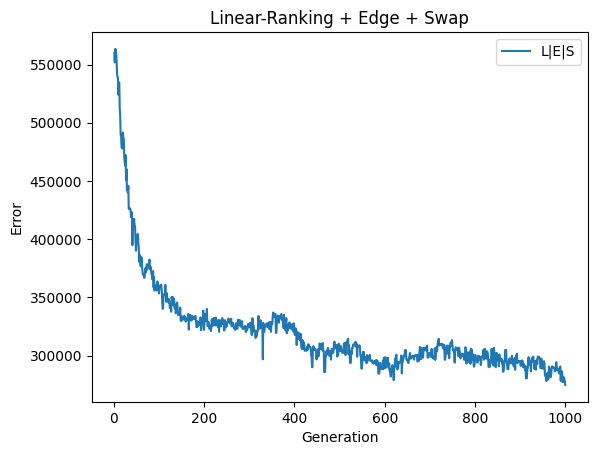

In [41]:
# report
print(f'best fitness of all generations: {1 / best_fitness}')
print(f"Time Spent to complete the algorithm is for {GENERATIONS}: {np.round(spent_time, 2)} seconds")

x = [i for i in range (1, GENERATIONS + 1)]
best_fitness_per_generation = [1 / best_fitness_per_generation[i] for i in range(len(best_fitness_per_generation))]

plt.plot(x, best_fitness_per_generation, label='L|E|S')

plt.xlabel('Generation')
plt.ylabel('Error')
plt.title('Linear-Ranking + Edge + Swap')

plt.legend()
plt.show()

In [42]:
# Best Route
best_individual

array([ 71,   5,   3,  21,  75, 125,  83, 116,  27,  42, 121,  24,  32,
        41,  25,  40, 104,  17,  73,  80,  81,  82,  74,  72,  89,   9,
       120,  26,  33,  35,  13,  30,  77,  78,  66,  22,  23,   6,   7,
        61,  19,  12, 102,  55,  54,  50,  46,  45, 110, 106, 126,  92,
        94,  96,  97, 100, 101, 108, 109,  70,  85,  86,  84,  62, 118,
        95,  69,  68,  88,  64,  48,  65,   0,  56,  49,  57, 112,  98,
        91,  63, 124, 103,  87,  60,  59,  90,  58, 105,   8,  16, 113,
         1,  10,  18,  11,   2, 115,  99, 107, 123,  51,  76,  20,  29,
        38,  31,  67,  36, 114,  93, 117,  52,  53,  39,  37,  79,  14,
        43,  44,  34, 122,  28, 119,  15,   4,  47, 111])

## EA (4): ##
*   Parent selection -> Linear Ranking
*   Cross Over -> Edge
*   Mutation -> Insert




In [44]:
population = initialize_population()
best_fitness_per_generation = []
best_fitness = 0

start = time.time()
for i in range(GENERATIONS):
  # print(f'Generation {i}:', end="")
  pop_fitness = [fitness(ind) for ind in population]

  f_best = np.max(pop_fitness)
  best_fitness_per_generation.append(f_best)

  if f_best > best_fitness:
    best_fitness = f_best
    best_individual = population[pop_fitness.index(f_best)]

  print(f'best fitness of generation {i+1}: {1 / f_best}')

  # Parent Selection:
  offspring = []
  population, probs = linear_ranking(population, pop_fitness, s = 1.5)
  for i in range(0, POPULATION_SIZE):
    p1 = roulette_wheel(probs, population)
    p2 = roulette_wheel(probs, population)
    while np.array_equal(p2, p1):
        p2 = roulette_wheel(probs, population)
    c1, c2 = edge_crossover(p1, p2), edge_crossover(p1, p2)
    while np.array_equal(c2, c1):
        c2 = edge_crossover(p1, p2)
    offspring.append(c1)
    offspring.append(c2)

  # Mutation
  mutated_offspring = []
  for i in range(len(offspring)):
    if np.random.rand() < MUTATION_RATE:
      mutated_offspring.append(insert_mutation(offspring[i]))
  offspring += mutated_offspring

  offspring_fitness = [fitness(ind) for ind in offspring]
  population += offspring
  pop_fitness += offspring_fitness
  # Survival selection
  nextgen = []
  i = 0
  population, probs = linear_ranking(population, pop_fitness, s = 1.5)
  while i < POPULATION_SIZE:
    p = roulette_wheel(probs, population)
    p = list(p)
    if p not in nextgen:
      nextgen.append(p)
      i += 1

  population = list(map(np.array, nextgen))

end = time.time()
spent_time = end - start

best fitness of generation 1: 576592.8677290868
best fitness of generation 2: 580436.9769907943
best fitness of generation 3: 557956.8019669428
best fitness of generation 4: 557956.8019669428
best fitness of generation 5: 557956.8019669428
best fitness of generation 6: 557956.8019669428
best fitness of generation 7: 549919.1650556775
best fitness of generation 8: 541716.4705095548
best fitness of generation 9: 538577.4952110889
best fitness of generation 10: 551356.2716624208
best fitness of generation 11: 523082.38309317
best fitness of generation 12: 532886.9495091283
best fitness of generation 13: 522665.6806255417
best fitness of generation 14: 510906.30116720713
best fitness of generation 15: 507281.26347674563
best fitness of generation 16: 502620.0111788926
best fitness of generation 17: 508454.81618816894
best fitness of generation 18: 505511.30977356766
best fitness of generation 19: 489164.24761572544
best fitness of generation 20: 492959.0007072411
best fitness of generation

best fitness of all generations: 269329.71328454633
Time Spent to complete the algorithm is for 1000: 805.36 seconds


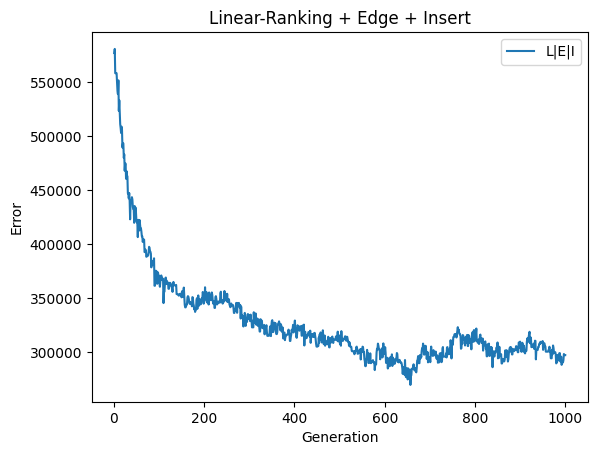

In [45]:
# report

print(f'best fitness of all generations: {1 / best_fitness}')
print(f"Time Spent to complete the algorithm is for {GENERATIONS}: {np.round(spent_time, 2)} seconds")

x = [i for i in range (1, GENERATIONS + 1)]
best_fitness_per_generation = [1 / best_fitness_per_generation[i] for i in range(len(best_fitness_per_generation))]

plt.plot(x, best_fitness_per_generation, label='L|E|I')

plt.xlabel('Generation')
plt.ylabel('Error')
plt.title('Linear-Ranking + Edge + Insert')

plt.legend()
plt.show()

In [46]:
# Best Route
best_individual

array([ 97,  96,  24,  33,  42,  34,  25, 121,  80,  67,  20,  11,  99,
        51, 123, 107,  18,   3,  26,  43,  48,  19,  35,  36,  49,  65,
        88,  64,  50,   1, 120,  56,  89,  91, 124,  98, 112,  72,  17,
        41, 122,  32,  40,   9,   8,   0, 105,   2, 115,  66,  10, 113,
        16, 104,  81, 101, 100,  82,  83,  59,  58,  73,  57,  90,  60,
        63, 103,  85,  87, 109,  68,  61,  23,  28,  31,  54,  46, 102,
        94,  92, 126, 106, 110, 111,  52,  93, 117,  45,  47,  53,  44,
        55,  13,  15,   5, 119,   6,  75, 116,  74, 108,  84,  86, 118,
        62, 125,  69,  95,  70,  79,  78,  76,  77,  38,  37,  29,  27,
        71,   7,  14,  21,  22,  12, 114,   4,  39,  30])

## EA (5): ##
*   Parent selection -> FPS
*   Cross Over -> PMX
*   Mutation -> Swap




In [47]:
population = initialize_population()
best_fitness_per_generation = []
best_fitness = 0

start = time.time()
for i in range(GENERATIONS):
  # print(f'Generation {i}:', end="")
  pop_fitness = [fitness(ind) for ind in population]

  f_best = np.max(pop_fitness)
  best_fitness_per_generation.append(f_best)

  if f_best > best_fitness:
    best_fitness = f_best
    best_individual = population[pop_fitness.index(f_best)]

  print(f'best fitness of generation {i+1}: {1 / f_best}')

  # Parent Selection:
  offspring = []
  probs = fps(pop_fitness)
  for i in range(0, POPULATION_SIZE):
    p1 = roulette_wheel(probs, population)
    p2 = roulette_wheel(probs, population)
    while np.array_equal(p2, p1):
        p2 = roulette_wheel(probs, population)
    c1, c2 = pmx_crossover(p1, p2)
    offspring.append(c1)
    offspring.append(c2)

  # Mutation
  mutated_offspring = []
  for i in range(len(offspring)):
    if np.random.rand() < MUTATION_RATE:
      mutated_offspring.append(swap_mutation(offspring[i]))
  offspring += mutated_offspring

  offspring_fitness = [fitness(ind) for ind in offspring]
  population += offspring
  pop_fitness += offspring_fitness

  # Survival selection
  nextgen = []
  i = 0
  probs = fps(pop_fitness)
  while i < POPULATION_SIZE:
    p = roulette_wheel(probs, population)
    p = list(p)
    if p not in nextgen:
      nextgen.append(p)
      i += 1

  population = list(map(np.array, nextgen))


end = time.time()
spent_time = end - start

best fitness of generation 1: 584373.1572690333
best fitness of generation 2: 575266.4329842664
best fitness of generation 3: 573841.9356441814
best fitness of generation 4: 573841.9356441814
best fitness of generation 5: 549441.9259710611
best fitness of generation 6: 561723.8579868777
best fitness of generation 7: 571969.1302957602
best fitness of generation 8: 571969.1302957602
best fitness of generation 9: 571969.1302957602
best fitness of generation 10: 575162.1015649664
best fitness of generation 11: 568783.3297977865
best fitness of generation 12: 552253.880761162
best fitness of generation 13: 552253.880761162
best fitness of generation 14: 581108.4223286153
best fitness of generation 15: 569671.7987244396
best fitness of generation 16: 566160.4848458698
best fitness of generation 17: 566528.5801172978
best fitness of generation 18: 568942.7817985608
best fitness of generation 19: 569851.3258732639
best fitness of generation 20: 557993.0823304298
best fitness of generation 21: 

best fitness of all generations: 531528.6455145231
Time Spent to complete the algorithm is for 1000: 190.83 seconds


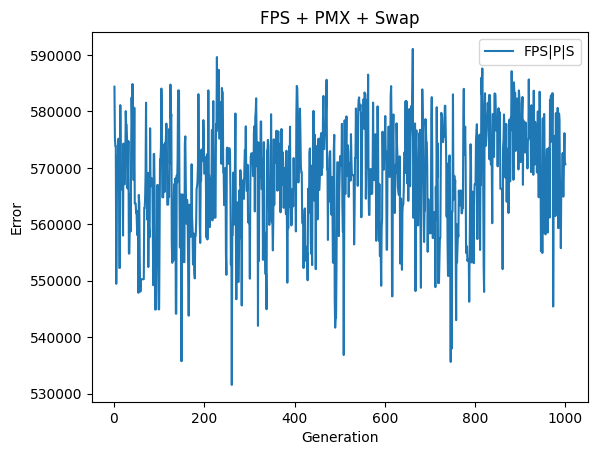

In [48]:
# report

print(f'best fitness of all generations: {1 / best_fitness}')
print(f"Time Spent to complete the algorithm is for {GENERATIONS}: {np.round(spent_time, 2)} seconds")

x = [i for i in range (1, GENERATIONS + 1)]
best_fitness_per_generation = [1 / best_fitness_per_generation[i] for i in range(len(best_fitness_per_generation))]

plt.plot(x, best_fitness_per_generation, label='FPS|P|S')

plt.xlabel('Generation')
plt.ylabel('Error')
plt.title('FPS + PMX + Swap')

plt.legend()
plt.show()

In [49]:
# Best Route
best_individual

array([113,  86,  40,  41,  18,  28,  70,  67,  21,  29,  62, 108,  85,
        69,   0, 105,  10, 116,  34,   6,  11, 118,  74, 111,  92,  48,
        79,  96, 126, 122,  49,  30, 124,  72,  77,  82, 117,  78,  53,
       123, 103,   9,  35, 119,  39,  65,  97,  31,  32,  57, 112,  60,
       109,  84,  80, 125,  94,   4,  50,  88,  59,  26,  87,  22,  25,
        33,  24,  52,  46,  54,  27,  45,  91,  93, 104,  36,  98,  17,
        44, 115,  73,  38, 101, 114,  12,  15,  47, 110, 106,  71,   3,
        23,  76, 121,  58,  89,  83,  14, 120,  55,   8,  66,  95,  81,
        51,  13,   2, 107,  75,  20,  43,  68,  56, 100,  90,  99,  63,
       102,  42,   1,  61,   5,  19,  37,   7,  16,  64])

## EA (6): ##
*   Parent selection -> FPS
*   Cross Over -> PMX
*   Mutation -> Insert




In [50]:
population = initialize_population()
best_fitness_per_generation = []
best_fitness = 0

start = time.time()
for i in range(GENERATIONS):
  # print(f'Generation {i}:', end="")
  pop_fitness = [fitness(ind) for ind in population]

  f_best = np.max(pop_fitness)
  best_fitness_per_generation.append(f_best)

  if f_best > best_fitness:
    best_fitness = f_best
    best_individual = population[pop_fitness.index(f_best)]

  print(f'best fitness of generation {i+1}: {1 / f_best}')

  # Parent Selection:
  offspring = []
  probs = fps(pop_fitness)
  for i in range(0, POPULATION_SIZE):
    p1 = roulette_wheel(probs, population)
    p2 = roulette_wheel(probs, population)
    while np.array_equal(p2, p1):
        p2 = roulette_wheel(probs, population)
    c1, c2 = pmx_crossover(p1, p2)
    offspring.append(c1)
    offspring.append(c2)

  # Mutation
  mutated_offspring = []
  for i in range(len(offspring)):
    if np.random.rand() < MUTATION_RATE:
      mutated_offspring.append(insert_mutation(offspring[i]))
  offspring += mutated_offspring

  offspring_fitness = [fitness(ind) for ind in offspring]
  population += offspring
  pop_fitness += offspring_fitness
  # Survival selection
  nextgen = []
  i = 0
  probs = fps(pop_fitness)
  while i < POPULATION_SIZE:
    p = roulette_wheel(probs, population)
    p = list(p)
    if p not in nextgen:
      nextgen.append(p)
      i += 1

  population = list(map(np.array, nextgen))



end = time.time()
spent_time = end - start

best fitness of generation 1: 577274.1786870591
best fitness of generation 2: 577227.6310468783
best fitness of generation 3: 577227.6310468783
best fitness of generation 4: 549587.9947391141
best fitness of generation 5: 549587.9947391141
best fitness of generation 6: 577199.6690192978
best fitness of generation 7: 580141.961034397
best fitness of generation 8: 576602.9493117324
best fitness of generation 9: 574550.9761942229
best fitness of generation 10: 578551.4365156386
best fitness of generation 11: 582402.168575496
best fitness of generation 12: 582402.168575496
best fitness of generation 13: 584149.8106843454
best fitness of generation 14: 592873.6413307778
best fitness of generation 15: 594054.6888516998
best fitness of generation 16: 582638.4546671894
best fitness of generation 17: 582638.4546671894
best fitness of generation 18: 565519.5176725114
best fitness of generation 19: 565519.5176725114
best fitness of generation 20: 565519.5176725114
best fitness of generation 21: 5

best fitness of all generations: 531832.6490383139
Time Spent to complete the algorithm is for 1000: 192.58 seconds


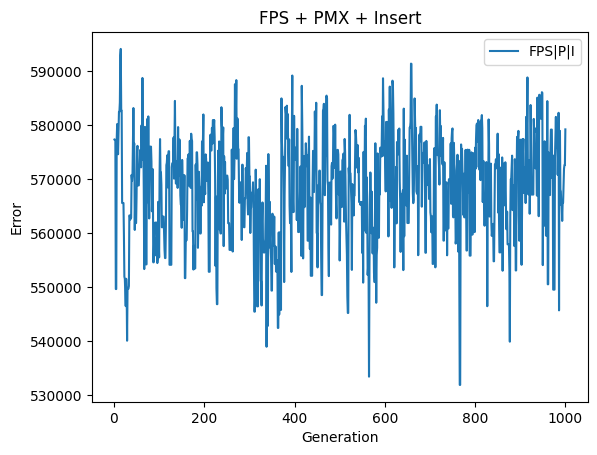

In [51]:
# report

print(f'best fitness of all generations: {1 / best_fitness}')
print(f"Time Spent to complete the algorithm is for {GENERATIONS}: {np.round(spent_time, 2)} seconds")

x = [i for i in range (1, GENERATIONS + 1)]
best_fitness_per_generation = [1 / best_fitness_per_generation[i] for i in range(len(best_fitness_per_generation))]

plt.plot(x, best_fitness_per_generation, label='FPS|P|I')

plt.xlabel('Generation')
plt.ylabel('Error')
plt.title('FPS + PMX + Insert')

plt.legend()
plt.show()

In [52]:
# Best Route
best_individual

array([  1,  43,  53,  94,  95,  32, 122,  27,  41,  28,  82, 114,  14,
         3,  71, 101, 100,  24,  78,  76,  31,  81,   7,  66, 123,  55,
        50,  33,  99,  38,  93,   8,  85,  39,  42,  56,  44, 126,  51,
       117, 124,  20, 111,  52,  92,  87,  37,  77,  75, 102,  84,  16,
        91, 107,  59, 109, 104,  69,  34,  57, 106, 121,  11,  35,  90,
        86, 103,  65,  30, 125,  29,  17, 118,  36,  45,  46,   4,   6,
        23, 108,  19,  18, 113,  25,  67,  80,  47, 110,  12,  10,  70,
       120,  49,  62,  73,  61,   9, 105, 119,  72,  79,  74,  96,  97,
        60, 115,  22,  26,   2,  15,  88,  98,  21,   5,  89,  13,  58,
        48,  68,  64, 112,  63,   0,  83,  54,  40, 116])

## EA (7): ##
*   Parent selection -> FPS
*   Cross Over -> Edge
*   Mutation -> Insert




In [53]:
population = initialize_population()
best_fitness_per_generation = []
best_fitness = 0

start = time.time()
for i in range(GENERATIONS):
  # print(f'Generation {i}:', end="")
  pop_fitness = [fitness(ind) for ind in population]

  f_best = np.max(pop_fitness)
  best_fitness_per_generation.append(f_best)

  if f_best > best_fitness:
    best_fitness = f_best
    best_individual = population[pop_fitness.index(f_best)]

  print(f'best fitness of generation {i+1}: {1 / f_best}')

  # Parent Selection:
  offspring = []
  probs = fps(pop_fitness)
  for i in range(0, POPULATION_SIZE):
    p1 = roulette_wheel(probs, population)
    p2 = roulette_wheel(probs, population)
    while np.array_equal(p2, p1):
        p2 = roulette_wheel(probs, population)
    c1, c2 = edge_crossover(p1, p2), edge_crossover(p1, p2)
    while np.array_equal(c2, c1):
        c2 = edge_crossover(p1, p2)
    offspring.append(c1)
    offspring.append(c2)

  # Mutation
  mutated_offspring = []
  for i in range(len(offspring)):
    if np.random.rand() < MUTATION_RATE:
      mutated_offspring.append(insert_mutation(offspring[i]))
  offspring += mutated_offspring

  offspring_fitness = [fitness(ind) for ind in offspring]
  population += offspring
  pop_fitness += offspring_fitness
  # Survival selection
  nextgen = []
  i = 0
  probs = fps(pop_fitness)
  while i < POPULATION_SIZE:
    p = roulette_wheel(probs, population)
    p = list(p)
    if p not in nextgen:
      nextgen.append(p)
      i += 1

  population = list(map(np.array, nextgen))



end = time.time()
spent_time = end - start

best fitness of generation 1: 560887.1352318915
best fitness of generation 2: 572439.8135604674
best fitness of generation 3: 574436.4588453668
best fitness of generation 4: 561008.3533710098
best fitness of generation 5: 554468.2948206333
best fitness of generation 6: 561039.3265598805
best fitness of generation 7: 565143.4261688811
best fitness of generation 8: 550193.3651363592
best fitness of generation 9: 550193.3651363592
best fitness of generation 10: 550193.3651363592
best fitness of generation 11: 574056.4814579574
best fitness of generation 12: 579692.5456707181
best fitness of generation 13: 575582.561241266
best fitness of generation 14: 559748.2711568446
best fitness of generation 15: 559748.2711568446
best fitness of generation 16: 575484.9647334007
best fitness of generation 17: 575484.9647334007
best fitness of generation 18: 556565.125550994
best fitness of generation 19: 555510.6869071956
best fitness of generation 20: 555510.6869071956
best fitness of generation 21: 

best fitness of all generations: 502278.7352164786
Time Spent to complete the algorithm is for 1000: 760.01 seconds


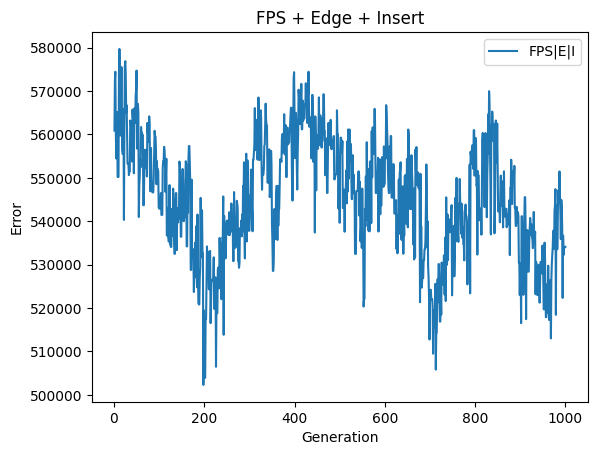

In [54]:
# report

print(f'best fitness of all generations: {1 / best_fitness}')
print(f"Time Spent to complete the algorithm is for {GENERATIONS}: {np.round(spent_time, 2)} seconds")

x = [i for i in range (1, GENERATIONS + 1)]
best_fitness_per_generation = [1 / best_fitness_per_generation[i] for i in range(len(best_fitness_per_generation))]

plt.plot(x, best_fitness_per_generation, label='FPS|E|I')

plt.xlabel('Generation')
plt.ylabel('Error')
plt.title('FPS + Edge + Insert')

plt.legend()
plt.show()

In [55]:
# Best Route
best_individual

array([ 38, 101, 100,  77,  12,   4,  33,  58,  45,  26,  64, 113, 121,
        32, 112,  89,  16, 120,  97,  20, 109, 125,  98, 124,  65,  60,
       105,  56,  48,  35,  57,  72,  74,   2,  49,  24,  40,  96,  88,
         9,  50, 114, 104,   8,  17,  42,  10, 123,  19,   3, 115,  27,
        91,  99,  18,  59,  61, 111,  31,  22,  15,  21,  82,  81,  73,
        66,  75,  37,  84,  55,  25, 122, 116,  43,  11,  67,  95,  86,
        28,  46, 106,  94,  68,  76,  36,  13,  51,  34,  83,  90, 107,
        41,  80,   0,   1,  47,  30,  71,  87,  70,  79,  14,  78,  29,
        44,  53,  93,  52,  39,   6, 119,   7,   5,  62,  69, 108,  23,
       102, 126,  92, 110,  63, 117,  54, 103,  85, 118])

## EA (8): ##
*   Parent selection -> FPS
*   Cross Over -> Edge
*   Mutation -> Swap




In [56]:
population = initialize_population()
best_fitness_per_generation = []
best_fitness = 0

start = time.time()
for i in range(GENERATIONS):
  # print(f'Generation {i}:', end="")
  pop_fitness = [fitness(ind) for ind in population]

  f_best = np.max(pop_fitness)
  best_fitness_per_generation.append(f_best)

  if f_best > best_fitness:
    best_fitness = f_best
    best_individual = population[pop_fitness.index(f_best)]

  print(f'best fitness of generation {i+1}: {1 / f_best}')

  # Parent Selection:
  offspring = []
  probs = fps(pop_fitness)
  for i in range(0, POPULATION_SIZE):
    p1 = roulette_wheel(probs, population)
    p2 = roulette_wheel(probs, population)
    while np.array_equal(p2, p1):
        p2 = roulette_wheel(probs, population)
    c1, c2 = edge_crossover(p1, p2), edge_crossover(p1, p2)
    while np.array_equal(c2, c1):
        c2 = edge_crossover(p1, p2)
    offspring.append(c1)
    offspring.append(c2)

  # Mutation
  mutated_offspring = []
  for i in range(len(offspring)):
    if np.random.rand() < MUTATION_RATE:
      mutated_offspring.append(swap_mutation(offspring[i]))
  offspring += mutated_offspring

  offspring_fitness = [fitness(ind) for ind in offspring]
  population += offspring
  pop_fitness += offspring_fitness
  # Survival selection
  nextgen = []
  i = 0
  probs = fps(pop_fitness)
  while i < POPULATION_SIZE:
    p = roulette_wheel(probs, population)
    p = list(p)
    if p not in nextgen:
      nextgen.append(p)
      i += 1

  population = list(map(np.array, nextgen))



end = time.time()
spent_time = end - start

best fitness of generation 1: 574888.6548562816
best fitness of generation 2: 575438.2311857728
best fitness of generation 3: 569756.3557587068
best fitness of generation 4: 578162.4087807231
best fitness of generation 5: 564320.6886302761
best fitness of generation 6: 564320.6886302761
best fitness of generation 7: 565123.2796750076
best fitness of generation 8: 569068.3987667641
best fitness of generation 9: 571177.8416972371
best fitness of generation 10: 565455.5300309517
best fitness of generation 11: 565455.5300309517
best fitness of generation 12: 565455.5300309517
best fitness of generation 13: 571177.6968528375
best fitness of generation 14: 559210.0684268258
best fitness of generation 15: 559210.0684268258
best fitness of generation 16: 564450.080989994
best fitness of generation 17: 564450.080989994
best fitness of generation 18: 559753.2534386249
best fitness of generation 19: 559753.2534386249
best fitness of generation 20: 564843.0235747859
best fitness of generation 21: 

best fitness of all generations: 512298.8299003274
Time Spent to complete the algorithm is for 1000: 760.44 seconds


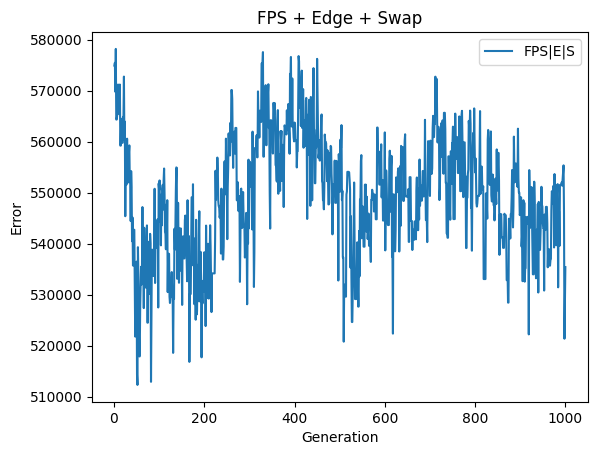

In [57]:
# report
print(f'best fitness of all generations: {1 / best_fitness}')
print(f"Time Spent to complete the algorithm is for {GENERATIONS}: {np.round(spent_time, 2)} seconds")

x = [i for i in range (1, GENERATIONS + 1)]
best_fitness_per_generation = [1 / best_fitness_per_generation[i] for i in range(len(best_fitness_per_generation))]

plt.plot(x, best_fitness_per_generation, label='FPS|E|S')

plt.xlabel('Generation')
plt.ylabel('Error')
plt.title('FPS + Edge + Swap')

plt.legend()
plt.show()

In [58]:
# Best Route
best_individual

array([ 70,  28,  83,  53,  29,  50,  75,  74, 116,  27,  12,  43,  51,
       123, 106,  41,   2,  66,  57,  88, 104,  10,   9,  97,  26, 101,
       118,  84,  85, 109, 113,  49,  40,  32,  17,  25,   0,  96, 105,
        18,  20,  77,  69, 117,  93,  45,  92,  35,  31,  52, 107,  55,
       124,  82, 100,  54,  14,  23,  87,  11,  37,  44,   4,  86,   8,
        56,  72,  73,  81,  24,  33, 121,  80,  48,  89,  64,  16,  34,
       122,  99, 120, 112,   1, 126, 125,  94, 102,  65,  90, 114,  22,
        68,  63,  13,  76,  59, 115, 108,  95, 103, 119,  46,  38,  47,
       110,   6,  15,  79,  36,   7,  71, 111,  39,  30,  78,  19,  98,
         3,  60,  58,  91,  42,  62,  67,   5,  21,  61])